In [5]:

print("Name: DHIVYA A")
print("Roll No: 24BAD020")
# PART A: DATASET PREPARATION AND TEXT PREPROCESSING

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters
vocab_size = 10000
max_len = 200

# Load IMDB dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("\nDataset Information")
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))
print("Positive reviews:", np.sum(y_train == 1))
print("Negative reviews:", np.sum(y_train == 0))

# Display sample encoded reviews
print("\nSample Review (encoded):")
print(x_train[0][:20])
print("Sample Sentiment:", "Positive" if y_train[0] == 1 else "Negative")

# Sequence padding
x_train = pad_sequences(x_train, maxlen=max_len, padding='post')
x_test = pad_sequences(x_test, maxlen=max_len, padding='post')

print("\nAfter Padding")
print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

# Validation split
x_val = x_train[:5000]
y_val = y_train[:5000]

x_train_new = x_train[5000:]
y_train_new = y_train[5000:]

print("\nFinal Dataset")
print("Training:", x_train_new.shape)
print("Validation:", x_val.shape)
print("Testing:", x_test.shape)

Name: DHIVYA A
Roll No: 24BAD020

Dataset Information
Training samples: 25000
Testing samples: 25000
Positive reviews: 12500
Negative reviews: 12500

Sample Review (encoded):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Sample Sentiment: Positive

After Padding
Training shape: (25000, 200)
Testing shape: (25000, 200)

Final Dataset
Training: (20000, 200)
Validation: (5000, 200)
Testing: (25000, 200)


In [6]:
# PART B: EMBEDDING GENERATION

import tensorflow as tf
from tensorflow.keras.layers import Embedding

# Parameters
vocab_size = 10000
embedding_dim = 64
max_len = 200

# Create Embedding layer
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_len
)

# Generate embeddings for training data
embedded_data = embedding_layer(x_train_new)

# Display shapes
print("\nEmbedding Information")
print("Vocabulary Size:", vocab_size)
print("Embedding Dimension:", embedding_dim)
print("Input Shape:", x_train_new.shape)
print("Embedding Shape:", embedded_data.shape)


Embedding Information
Vocabulary Size: 10000
Embedding Dimension: 64
Input Shape: (20000, 200)
Embedding Shape: (20000, 200, 64)


In [7]:
# PART C: IMPLEMENTING THE LSTM MODEL

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Parameters
vocab_size = 10000
embedding_dim = 64
max_len = 200

# Create LSTM model
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

# Display model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 294ms/step - accuracy: 0.6185 - loss: 0.6538 - val_accuracy: 0.7192 - val_loss: 0.5910
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 358ms/step - accuracy: 0.6630 - loss: 0.6301 - val_accuracy: 0.5452 - val_loss: 0.7305
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 302ms/step - accuracy: 0.6481 - loss: 0.6096 - val_accuracy: 0.7948 - val_loss: 0.4821
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 305ms/step - accuracy: 0.6192 - loss: 0.6390 - val_accuracy: 0.5984 - val_loss: 0.6357
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 309ms/step - accuracy: 0.6510 - loss: 0.6150 - val_accuracy: 0.7920 - val_loss: 0.5842

Test Loss: 0.593
Test Accuracy: 0.7828

Evaluation Metrics
Accuracy : 0.7828
Precision: 0.7574
Recall   : 0.8321
F1-Score : 0.793


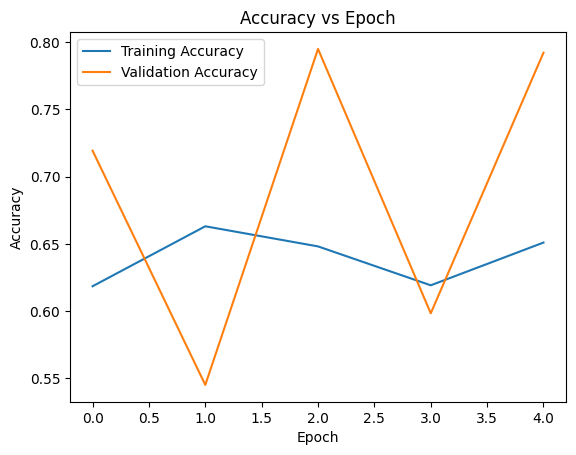

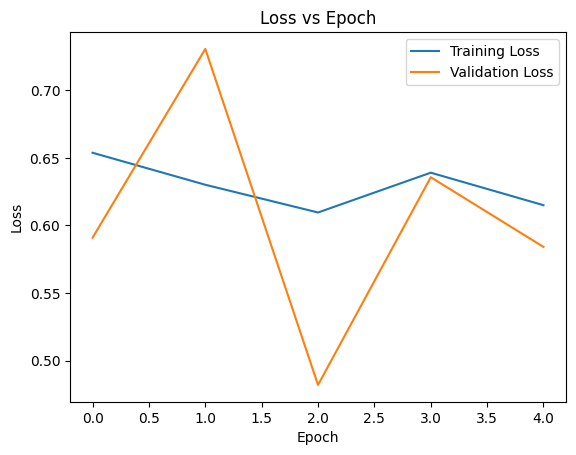

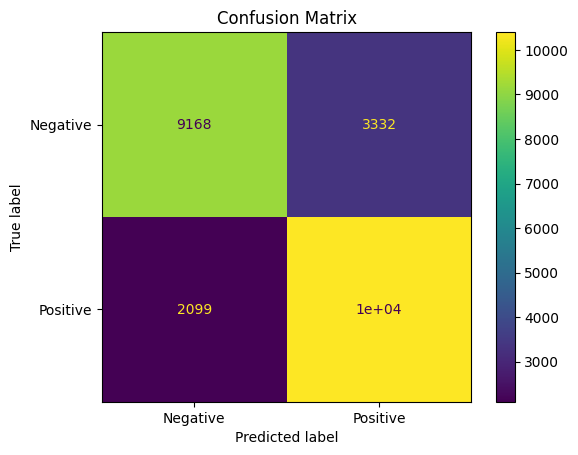

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Sample Predictions

Review: This movie was excellent and I really enjoyed it
Predicted Sentiment: Positive

Review: The movie was boring and disappointing
Predicted Sentiment: Positive


In [8]:
# PART D: MODEL TRAINING AND SENTIMENT PREDICTION
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Train the model
history = model.fit(
    x_train_new, y_train_new,
    epochs=5,
    batch_size=128,
    validation_data=(x_val, y_val))
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print("\nTest Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))
# Predictions
y_prob = model.predict(x_test, verbose=0)
y_pred = (y_prob >= 0.5).astype(int).flatten()
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("\nEvaluation Metrics")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

# Accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Sample sentiment prediction
sample_reviews = [
    "This movie was excellent and I really enjoyed it",
    "The movie was boring and disappointing"
]

# Convert sample reviews into word-index sequences
word_index = imdb.get_word_index()

sequences = []
for review in sample_reviews:
    words = review.lower().split()
    sequence = [word_index.get(word, 2) + 3 for word in words]
    sequences.append(sequence)

sample_padded = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post'
)

predictions = model.predict(sample_padded, verbose=0)

print("\nSample Predictions")

for review, prediction in zip(sample_reviews, predictions):
    sentiment = "Positive" if prediction[0] >= 0.5 else "Negative"
    print("\nReview:", review)
    print("Predicted Sentiment:", sentiment)